# Metals Cross-Sectional Dollar Bars

Build cross-sectional dollar bars for the liquid metals complex:

```python
ROOTS = ["GC", "SI", "HG", "PL", "PA", "ALI"]
```

The main clock uses **$250M** of traded contract notional per bar. A sensitivity panel compares **$100M**, **$250M**, **$500M**, and **$1B** bars.

The bar clock is cross-sectional: trades from every root are sorted by timestamp, accumulated together, and a new bar closes when the complex reaches the target notional. Each bar records the individual notional and trade-count contribution of each root.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

In [2]:
TRADE_DIR = Path("/home/famadeo/research/databento-asset-browser/data/metals_trades_12m/outright")
CACHE_DIR = Path("../../data/features/metals_cross_sectional_dollar_bars").resolve()
CACHE_DIR.mkdir(parents=True, exist_ok=True)

ROOTS = ["GC", "SI", "HG", "PL", "PA", "ALI"]
PRIMARY_THRESHOLD = 250_000_000.0
THRESHOLDS = [100_000_000.0, 250_000_000.0, 500_000_000.0, 1_000_000_000.0]

# Contract multipliers used to convert trade price x contracts to dollar notional.
# GC: 100 troy oz, SI: 5,000 troy oz, HG: 25,000 lb, PL: 50 troy oz,
# PA: 100 troy oz, ALI: 25 metric tons.
CONTRACT_MULTIPLIER = {
    "GC": 100.0,
    "SI": 5_000.0,
    "HG": 25_000.0,
    "PL": 50.0,
    "PA": 100.0,
    "ALI": 25.0,
}

# Last 30 available calendar days in the current metals trade sample.
START = pd.Timestamp("2026-05-24T00:00:00Z")
END = pd.Timestamp("2026-06-22T00:00:00Z")

## Load Trades

The notebook uses the 12-month Databento trade files already available locally. `notional = price * size * contract_multiplier`.

This is a trade-notional clock, not an execution-cost model.

In [3]:
def load_trade_notional(start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    cache_path = CACHE_DIR / f"trades_{start:%Y%m%d}_{end:%Y%m%d}.parquet"
    if cache_path.exists():
        trades = pd.read_parquet(cache_path)
        trades["ts_event"] = pd.to_datetime(trades["ts_event"], utc=True)
        return trades

    frames = []
    for root in ROOTS:
        path = TRADE_DIR / f"{root}.parquet"
        if not path.exists():
            continue
        frame = (
            pl.scan_parquet(str(path))
            .select(["ts_event", "price", "size", "side"])
            .filter(
                (pl.col("ts_event") >= start.to_pydatetime())
                & (pl.col("ts_event") < end.to_pydatetime())
                & (pl.col("price") > 0)
                & (pl.col("size") > 0)
            )
            .with_columns(
                [
                    pl.lit(root).alias("root"),
                    (pl.col("price") * pl.col("size") * CONTRACT_MULTIPLIER[root]).alias(
                        "notional"
                    ),
                    pl.when(pl.col("side") == "B")
                    .then(pl.col("price") * pl.col("size") * CONTRACT_MULTIPLIER[root])
                    .when(pl.col("side") == "A")
                    .then(-pl.col("price") * pl.col("size") * CONTRACT_MULTIPLIER[root])
                    .otherwise(0.0)
                    .alias("signed_notional"),
                ]
            )
        )
        frames.append(frame)

    trades_pl = pl.concat(frames).sort(["ts_event", "root"]).collect(engine="streaming")
    trades = trades_pl.to_pandas()
    trades["ts_event"] = pd.to_datetime(trades["ts_event"], utc=True)
    trades.to_parquet(cache_path, index=False)
    return trades


trades = load_trade_notional(START, END)
print(
    f"Loaded {len(trades):,} trades from {trades['ts_event'].min()} to {trades['ts_event'].max()}"
)
print(f"Total complex notional: ${trades['notional'].sum() / 1e12:,.2f}T")
trades.head()

Loaded 3,292,329 trades from 2026-05-24 22:00:00+00:00 to 2026-06-21 23:59:56.506287451+00:00
Total complex notional: $1.55T


,ts_event,price,size,side,root,notional,signed_notional
0,2026-05-24 22:00:00+00:00,4532.000,42.0,N,GC,19034400.0,0.0
1,2026-05-24 22:00:00+00:00,4566.000,35.0,N,GC,15981000.0,0.0
2,2026-05-24 22:00:00+00:00,6.418,22.0,N,HG,3529900.0,0.0
3,2026-05-24 22:00:00+00:00,6.460,5.0,N,HG,807500.0,0.0
4,2026-05-24 22:00:00+00:00,6.411,4.0,N,HG,641100.0,0.0


In [4]:
trade_summary = (
    trades.groupby("root")
    .agg(
        trades=("notional", "size"),
        total_notional=("notional", "sum"),
        median_trade_notional=("notional", "median"),
        p90_trade_notional=("notional", lambda x: x.quantile(0.90)),
        p99_trade_notional=("notional", lambda x: x.quantile(0.99)),
        signed_notional=("signed_notional", "sum"),
    )
    .reset_index()
)
trade_summary["notional_share"] = (
    trade_summary["total_notional"] / trade_summary["total_notional"].sum()
)
trade_summary["trades_share"] = trade_summary["trades"] / trade_summary["trades"].sum()
trade_summary = trade_summary.sort_values("total_notional", ascending=False)
display(trade_summary)

,root,trades,total_notional,median_trade_notional,p90_trade_notional,p99_trade_notional,signed_notional,notional_share,trades_share
1,GC,1956336,1.142153e+12,446590.000,897900.00,2244900.0,-1.084952e+10,0.734816,0.594210
5,SI,561863,2.510142e+11,355750.000,704300.00,1663797.5,-1.527734e+09,0.161493,0.170658
2,HG,477996,1.225606e+11,162400.000,477600.00,1242115.0,-1.693626e+09,0.078851,0.145185
4,PL,228371,2.666998e+10,92230.000,180200.00,481250.0,1.598032e+08,0.017158,0.069365
3,PA,62085,1.132053e+10,136800.000,278900.00,686790.0,-6.633105e+07,0.007283,0.018857
0,ALI,5678,6.201468e+08,91015.625,174036.25,375146.0,8.996838e+06,0.000399,0.001725


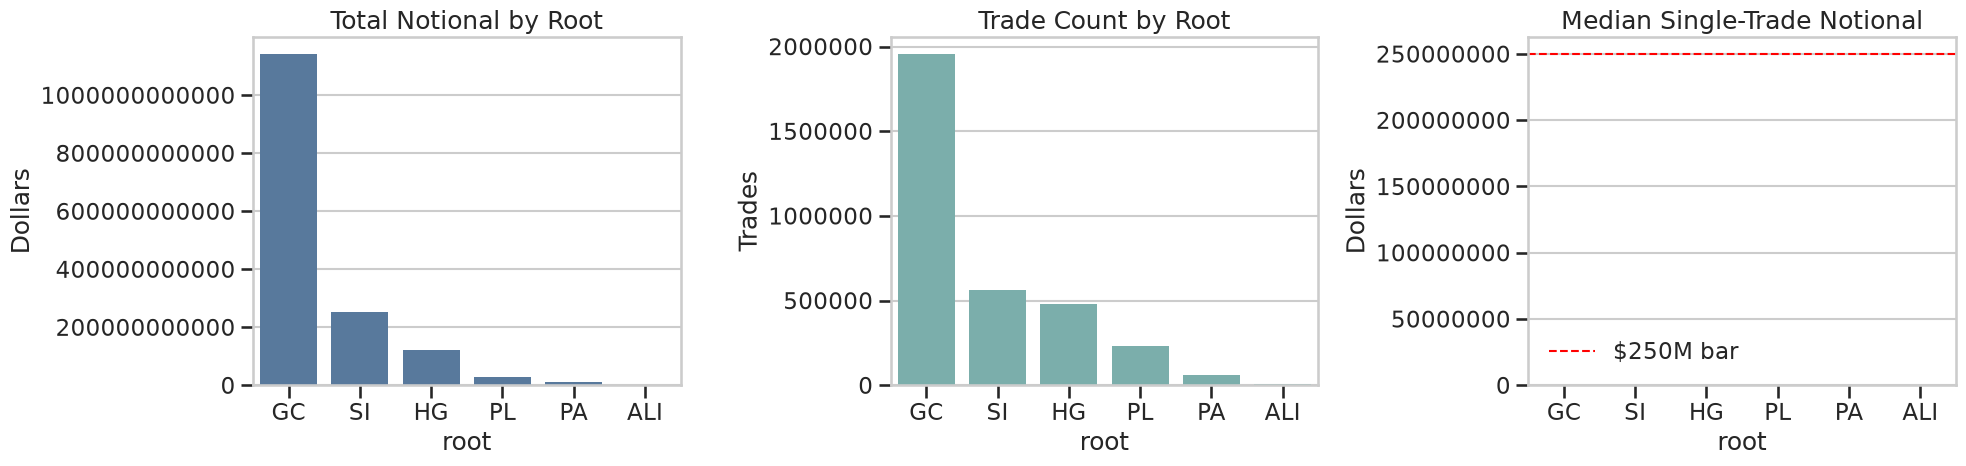

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.barplot(data=trade_summary, x="root", y="total_notional", ax=axes[0], color="#4C78A8")
axes[0].set_title("Total Notional by Root")
axes[0].set_ylabel("Dollars")
axes[0].ticklabel_format(style="plain", axis="y")

sns.barplot(data=trade_summary, x="root", y="trades", ax=axes[1], color="#72B7B2")
axes[1].set_title("Trade Count by Root")
axes[1].set_ylabel("Trades")
axes[1].ticklabel_format(style="plain", axis="y")

sns.barplot(data=trade_summary, x="root", y="median_trade_notional", ax=axes[2], color="#F58518")
axes[2].axhline(PRIMARY_THRESHOLD, color="red", linestyle="--", linewidth=1.5, label="$250M bar")
axes[2].set_title("Median Single-Trade Notional")
axes[2].set_ylabel("Dollars")
axes[2].legend()
axes[2].ticklabel_format(style="plain", axis="y")
plt.tight_layout()

## Build Cross-Sectional Dollar Bars

The builder is sequential by design. A bar starts with the next trade and closes when accumulated complex notional reaches the threshold. The final incomplete bar is retained but excluded from most summary plots.

In [6]:
def build_cross_sectional_dollar_bars(trades: pd.DataFrame, threshold: float) -> pd.DataFrame:
    cache_path = CACHE_DIR / f"bars_{int(threshold)}_{START:%Y%m%d}_{END:%Y%m%d}.parquet"
    if cache_path.exists():
        bars = pd.read_parquet(cache_path)
        bars["start_ts"] = pd.to_datetime(bars["start_ts"], utc=True)
        bars["end_ts"] = pd.to_datetime(bars["end_ts"], utc=True)
        return bars

    ordered = trades.sort_values(["ts_event", "root"]).reset_index(drop=True)
    root_to_id = {root: i for i, root in enumerate(ROOTS)}
    root_ids = ordered["root"].map(root_to_id).to_numpy(np.int16)
    notionals = ordered["notional"].to_numpy(float)
    signed_notionals = ordered["signed_notional"].to_numpy(float)
    timestamps = ordered["ts_event"].to_numpy()

    rows = []
    contrib_notional = []
    contrib_signed = []
    contrib_trades = []

    cur_notional_by_root = np.zeros(len(ROOTS), dtype=float)
    cur_signed_by_root = np.zeros(len(ROOTS), dtype=float)
    cur_trades_by_root = np.zeros(len(ROOTS), dtype=np.int32)
    cur_notional = 0.0
    cur_trades = 0
    start_ts = None
    bar_id = 0

    for i, (root_id, notional, signed_notional) in enumerate(
        zip(root_ids, notionals, signed_notionals, strict=False)
    ):
        if cur_trades == 0:
            start_ts = timestamps[i]

        cur_notional_by_root[root_id] += notional
        cur_signed_by_root[root_id] += signed_notional
        cur_trades_by_root[root_id] += 1
        cur_notional += notional
        cur_trades += 1

        if cur_notional >= threshold:
            rows.append((bar_id, start_ts, timestamps[i], cur_notional, cur_trades, True))
            contrib_notional.append(cur_notional_by_root.copy())
            contrib_signed.append(cur_signed_by_root.copy())
            contrib_trades.append(cur_trades_by_root.copy())
            cur_notional_by_root.fill(0.0)
            cur_signed_by_root.fill(0.0)
            cur_trades_by_root.fill(0)
            cur_notional = 0.0
            cur_trades = 0
            start_ts = None
            bar_id += 1

    if cur_trades:
        rows.append((bar_id, start_ts, timestamps[-1], cur_notional, cur_trades, False))
        contrib_notional.append(cur_notional_by_root.copy())
        contrib_signed.append(cur_signed_by_root.copy())
        contrib_trades.append(cur_trades_by_root.copy())

    bars = pd.DataFrame(
        rows, columns=["bar_id", "start_ts", "end_ts", "bar_notional", "trades", "complete"]
    )
    notional_frame = pd.DataFrame(
        np.vstack(contrib_notional), columns=[f"{root}_notional" for root in ROOTS]
    )
    signed_frame = pd.DataFrame(
        np.vstack(contrib_signed), columns=[f"{root}_signed_notional" for root in ROOTS]
    )
    count_frame = pd.DataFrame(
        np.vstack(contrib_trades), columns=[f"{root}_trades" for root in ROOTS]
    )
    bars = pd.concat([bars, notional_frame, signed_frame, count_frame], axis=1)
    bars["start_ts"] = pd.to_datetime(bars["start_ts"], utc=True)
    bars["end_ts"] = pd.to_datetime(bars["end_ts"], utc=True)
    bars["duration_seconds"] = (bars["end_ts"] - bars["start_ts"]).dt.total_seconds()
    bars["overshoot_pct"] = bars["bar_notional"] / threshold - 1.0
    bars["threshold"] = threshold

    notional_cols = [f"{root}_notional" for root in ROOTS]
    signed_cols = [f"{root}_signed_notional" for root in ROOTS]
    trade_cols = [f"{root}_trades" for root in ROOTS]
    share = bars[notional_cols].div(bars["bar_notional"].replace(0, np.nan), axis=0).fillna(0.0)
    trade_share = bars[trade_cols].div(bars["trades"].replace(0, np.nan), axis=0).fillna(0.0)
    signed_ratio = (
        bars[signed_cols].to_numpy().sum(axis=1)
        / bars["bar_notional"].replace(0, np.nan).to_numpy()
    )
    bars["dominant_root"] = share.idxmax(axis=1).str.replace("_notional", "", regex=False)
    bars["dominant_share"] = share.max(axis=1)
    bars["hhi_notional_share"] = (share**2).sum(axis=1)
    bars["hhi_trade_share"] = (trade_share**2).sum(axis=1)
    bars["complex_signed_notional_ratio"] = np.nan_to_num(signed_ratio)
    bars.to_parquet(cache_path, index=False)
    return bars


bars_by_threshold = {
    threshold: build_cross_sectional_dollar_bars(trades, threshold) for threshold in THRESHOLDS
}
primary_bars = bars_by_threshold[PRIMARY_THRESHOLD]
primary_complete = primary_bars[primary_bars["complete"]].copy()
print(f"Primary ${PRIMARY_THRESHOLD/1e6:.0f}M bars: {len(primary_complete):,} complete bars")
primary_complete.head()

Primary $250M bars: 6,204 complete bars


,bar_id,start_ts,end_ts,bar_notional,trades,complete,GC_notional,SI_notional,HG_notional,PL_notional,PA_notional,ALI_notional,GC_signed_notional,SI_signed_notional,HG_signed_notional,PL_signed_notional,PA_signed_notional,ALI_signed_notional,GC_trades,SI_trades,HG_trades,PL_trades,PA_trades,ALI_trades,duration_seconds,overshoot_pct,threshold,dominant_root,dominant_share,hhi_notional_share,hhi_trade_share,complex_signed_notional_ratio
0,0,2026-05-24 22:00:00+00:00,2026-05-24 22:00:09.039270991+00:00,250281017.5,414,True,177288630.0,39236100.0,28927612.5,2625525.0,2203150.0,0.0,29105790.0,19616675.0,14778450.0,390835.0,1107800.0,0.0,256,64,64,20,10,0,9.039271,0.001124,250000000.0,GC,0.708358,0.539894,0.433079,0.259706
1,1,2026-05-24 22:00:09.056361085+00:00,2026-05-24 22:01:03.992583503+00:00,250258742.5,484,True,168700000.0,64359400.0,13881237.5,2631705.0,686400.0,0.0,13637930.0,-3443675.0,-1887.5,-681665.0,412100.0,0.0,282,125,53,19,5,0,54.936222,0.001035,250000000.0,GC,0.674102,0.523746,0.419814,0.039650
2,2,2026-05-24 22:01:03.992583503+00:00,2026-05-24 22:02:17.013011735+00:00,251353270.0,517,True,168351420.0,58044675.0,15305275.0,6752250.0,2899650.0,0.0,-17662730.0,26703325.0,-2093650.0,3132440.0,828950.0,0.0,316,108,46,35,12,0,73.020428,0.005413,250000000.0,GC,0.669780,0.506496,0.430265,0.043398
3,3,2026-05-24 22:02:17.042944613+00:00,2026-05-24 22:04:06.359046725+00:00,250224537.5,514,True,145251000.0,84995625.0,10462212.5,7161550.0,2354150.0,0.0,-14129640.0,-8574925.0,-1770912.5,-1362555.0,-553600.0,0.0,265,143,42,48,16,0,109.316102,0.000898,250000000.0,GC,0.580483,0.454997,0.359574,-0.105472
4,4,2026-05-24 22:04:07.259041207+00:00,2026-05-24 22:05:27.282327063+00:00,253540807.5,470,True,174501720.0,67628675.0,7745912.5,2553850.0,1110650.0,0.0,14137010.0,-5034550.0,2091937.5,494080.0,412350.0,0.0,271,136,39,16,8,0,80.023286,0.014163,250000000.0,GC,0.688259,0.545903,0.424527,0.047727


In [7]:
def summarize_bars(bars: pd.DataFrame) -> dict:
    complete = bars[bars["complete"]].copy()
    days = max(
        (complete["end_ts"].max() - complete["start_ts"].min()).total_seconds() / 86_400, 1e-9
    )
    return {
        "threshold_m": complete["threshold"].iloc[0] / 1e6,
        "complete_bars": len(complete),
        "bars_per_day": len(complete) / days,
        "median_duration_sec": complete["duration_seconds"].median(),
        "p90_duration_sec": complete["duration_seconds"].quantile(0.90),
        "median_trades_per_bar": complete["trades"].median(),
        "median_notional_m": complete["bar_notional"].median() / 1e6,
        "median_overshoot_pct": complete["overshoot_pct"].median(),
        "median_dominant_share": complete["dominant_share"].median(),
        "median_hhi_notional_share": complete["hhi_notional_share"].median(),
    }


sensitivity = pd.DataFrame([summarize_bars(bars) for bars in bars_by_threshold.values()])
display(sensitivity)

,threshold_m,complete_bars,bars_per_day,median_duration_sec,p90_duration_sec,median_trades_per_bar,median_notional_m,median_overshoot_pct,median_dominant_share,median_hhi_notional_share
0,100.0,15465,550.699710,73.160170,236.676723,213.0,100.259960,0.002600,0.752341,0.598839
1,250.0,6204,220.941231,192.903512,572.217979,531.0,250.258085,0.001032,0.745081,0.588950
2,500.0,3105,110.594984,396.984872,1109.845325,1061.0,500.250482,0.000501,0.740850,0.584663
3,1000.0,1553,55.327812,818.145684,2248.283354,2116.0,1000.254373,0.000254,0.738770,0.579189


## Sensitivity: $100M, $250M, $500M, $1B

The key question is whether the bars are too fast and too dominated by one root. The practical sweet spot is where bars are frequent enough for intraday analysis but slow enough to show complex-level composition rather than isolated prints.

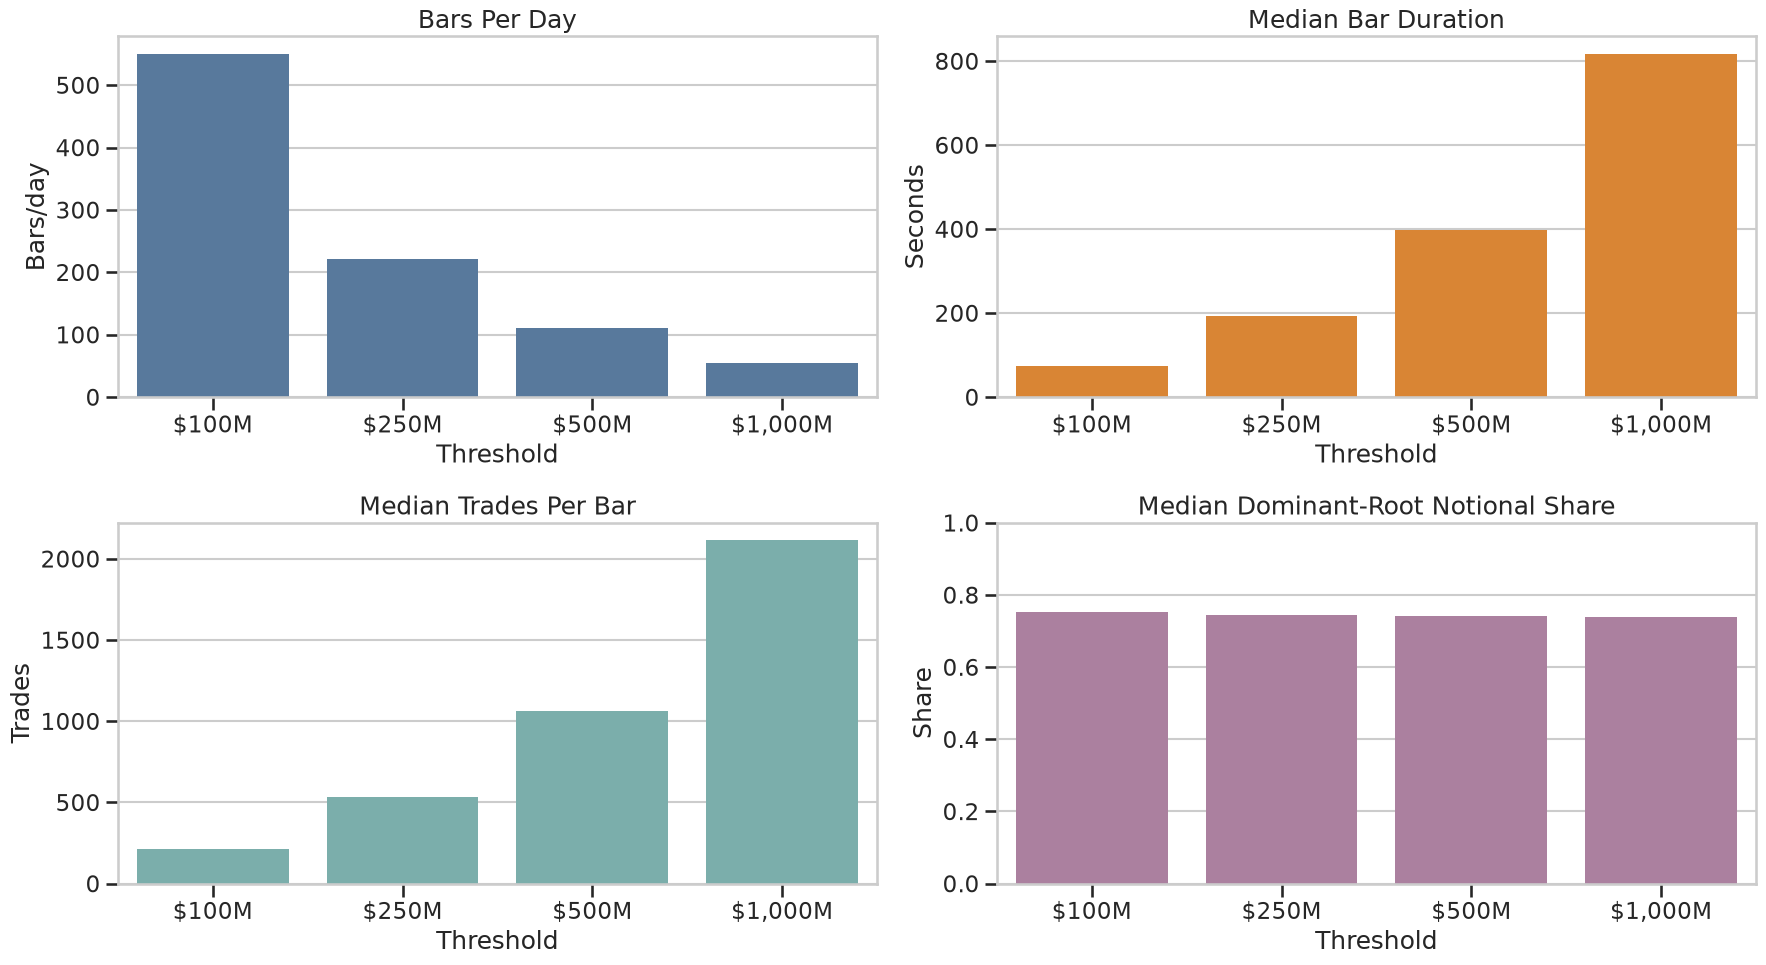

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
plot = sensitivity.copy()
plot["threshold_label"] = plot["threshold_m"].map(lambda x: f"${x:,.0f}M")

sns.barplot(data=plot, x="threshold_label", y="bars_per_day", ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Bars Per Day")
axes[0, 0].set_xlabel("Threshold")
axes[0, 0].set_ylabel("Bars/day")

sns.barplot(data=plot, x="threshold_label", y="median_duration_sec", ax=axes[0, 1], color="#F58518")
axes[0, 1].set_title("Median Bar Duration")
axes[0, 1].set_xlabel("Threshold")
axes[0, 1].set_ylabel("Seconds")

sns.barplot(
    data=plot, x="threshold_label", y="median_trades_per_bar", ax=axes[1, 0], color="#72B7B2"
)
axes[1, 0].set_title("Median Trades Per Bar")
axes[1, 0].set_xlabel("Threshold")
axes[1, 0].set_ylabel("Trades")

sns.barplot(
    data=plot, x="threshold_label", y="median_dominant_share", ax=axes[1, 1], color="#B279A2"
)
axes[1, 1].set_title("Median Dominant-Root Notional Share")
axes[1, 1].set_xlabel("Threshold")
axes[1, 1].set_ylabel("Share")
axes[1, 1].set_ylim(0, 1)
plt.tight_layout()

In [9]:
share_rows = []
for threshold, bars in bars_by_threshold.items():
    complete = bars[bars["complete"]].copy()
    for root in ROOTS:
        share_rows.append(
            {
                "threshold_m": threshold / 1e6,
                "root": root,
                "mean_notional_share": (
                    complete[f"{root}_notional"] / complete["bar_notional"]
                ).mean(),
                "mean_trade_share": (complete[f"{root}_trades"] / complete["trades"]).mean(),
                "dominant_fraction": (complete["dominant_root"] == root).mean(),
            }
        )
share_summary = pd.DataFrame(share_rows)
display(share_summary.pivot(index="root", columns="threshold_m", values="mean_notional_share"))

threshold_m,100.0,250.0,500.0,1000.0
root,,,,
ALI,0.000399,0.000399,0.000399,0.000399
GC,0.734669,0.734745,0.734771,0.734766
HG,0.078893,0.078877,0.078865,0.078868
PA,0.007288,0.007285,0.007285,0.007285
PL,0.017171,0.017163,0.017163,0.017164
SI,0.161579,0.161532,0.161516,0.161518


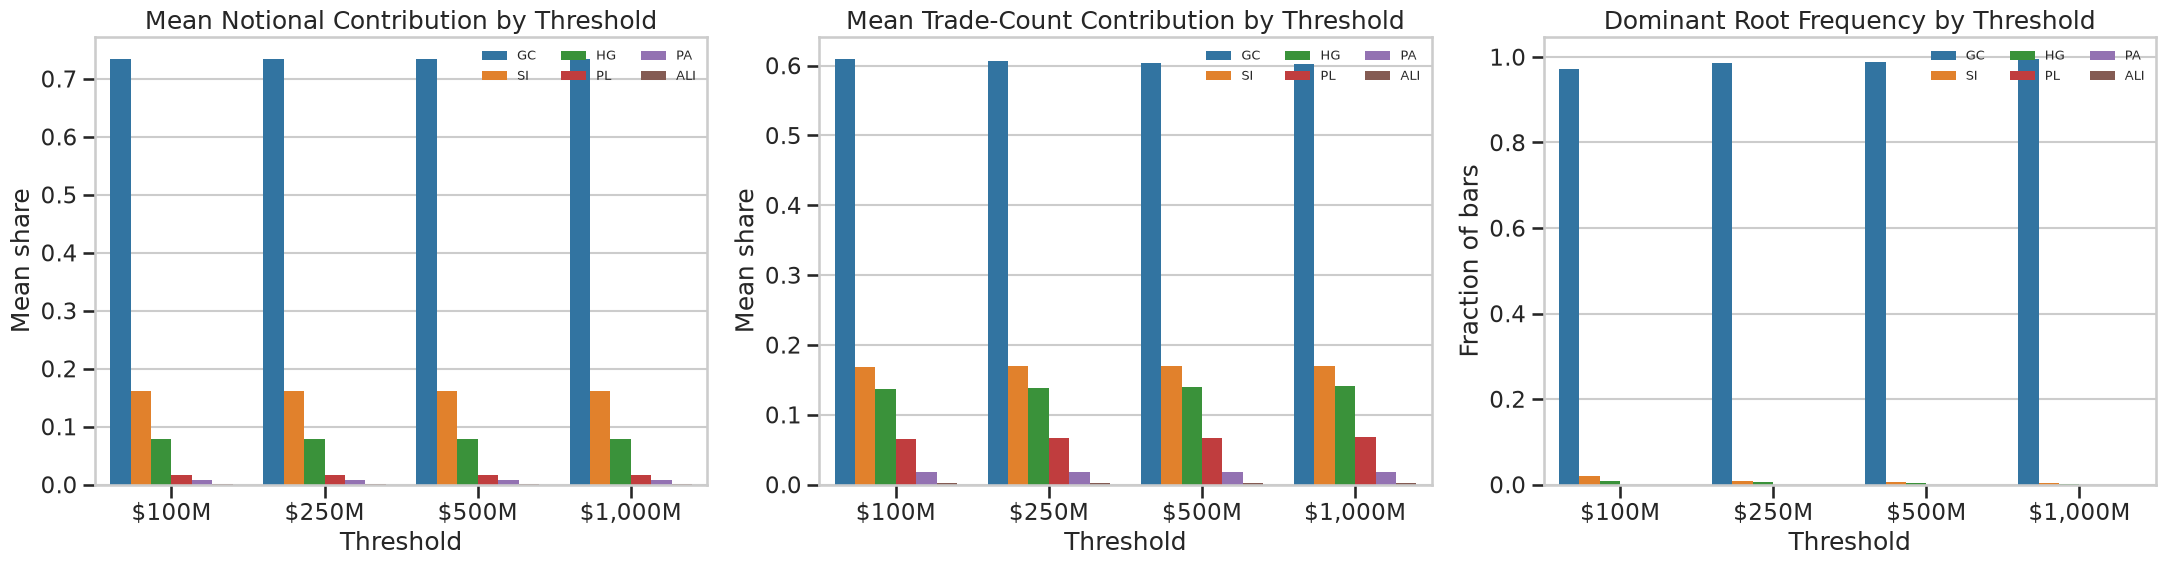

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
share_plot = share_summary.copy()
share_plot["threshold_label"] = share_plot["threshold_m"].map(lambda x: f"${x:,.0f}M")

sns.barplot(data=share_plot, x="threshold_label", y="mean_notional_share", hue="root", ax=axes[0])
axes[0].set_title("Mean Notional Contribution by Threshold")
axes[0].set_ylabel("Mean share")
axes[0].set_xlabel("Threshold")
axes[0].legend(ncols=3, fontsize=9)

sns.barplot(data=share_plot, x="threshold_label", y="mean_trade_share", hue="root", ax=axes[1])
axes[1].set_title("Mean Trade-Count Contribution by Threshold")
axes[1].set_ylabel("Mean share")
axes[1].set_xlabel("Threshold")
axes[1].legend(ncols=3, fontsize=9)

sns.barplot(data=share_plot, x="threshold_label", y="dominant_fraction", hue="root", ax=axes[2])
axes[2].set_title("Dominant Root Frequency by Threshold")
axes[2].set_ylabel("Fraction of bars")
axes[2].set_xlabel("Threshold")
axes[2].legend(ncols=3, fontsize=9)
plt.tight_layout()

## Primary $250M Bars

In [11]:
primary_stats = (
    primary_complete[
        [
            "bar_notional",
            "duration_seconds",
            "trades",
            "overshoot_pct",
            "dominant_share",
            "hhi_notional_share",
            "complex_signed_notional_ratio",
        ]
    ]
    .describe(percentiles=[0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99])
    .T
)
primary_stats

,count,mean,std,min,1%,10%,25%,50%,75%,90%,99%,max
bar_notional,6204.0,2.505066e+08,1.903111e+06,2.500000e+08,2.500044e+08,2.500498e+08,2.501164e+08,2.502581e+08,2.504214e+08,2.508497e+08,2.541590e+08,3.255387e+08
duration_seconds,6204.0,3.906127e+02,4.586095e+03,3.498005e-01,8.900667e+00,4.639001e+01,9.450300e+01,1.929035e+02,3.603779e+02,5.722180e+02,1.194277e+03,1.909560e+05
trades,6204.0,5.306148e+02,7.076587e+01,1.810000e+02,3.530300e+02,4.420000e+02,4.860000e+02,5.310000e+02,5.762500e+02,6.170000e+02,6.970000e+02,9.310000e+02
overshoot_pct,6204.0,2.026261e-03,7.612443e-03,5.000000e-08,1.775330e-05,1.993090e-04,4.656775e-04,1.032340e-03,1.685578e-03,3.398690e-03,1.663612e-02,3.021548e-01
dominant_share,6204.0,7.382993e-01,1.077832e-01,3.490583e-01,4.635560e-01,5.934677e-01,6.671841e-01,7.450806e-01,8.153220e-01,8.726726e-01,9.540974e-01,9.881925e-01
hhi_notional_share,6204.0,5.989332e-01,1.256001e-01,2.768875e-01,3.612138e-01,4.427591e-01,5.044827e-01,5.889505e-01,6.826371e-01,7.694729e-01,9.113488e-01,9.765863e-01
complex_signed_notional_ratio,6204.0,-8.925770e-03,1.337692e-01,-7.781117e-01,-3.453459e-01,-1.728814e-01,-9.281124e-02,-7.699917e-03,7.881279e-02,1.532058e-01,3.163755e-01,5.944584e-01


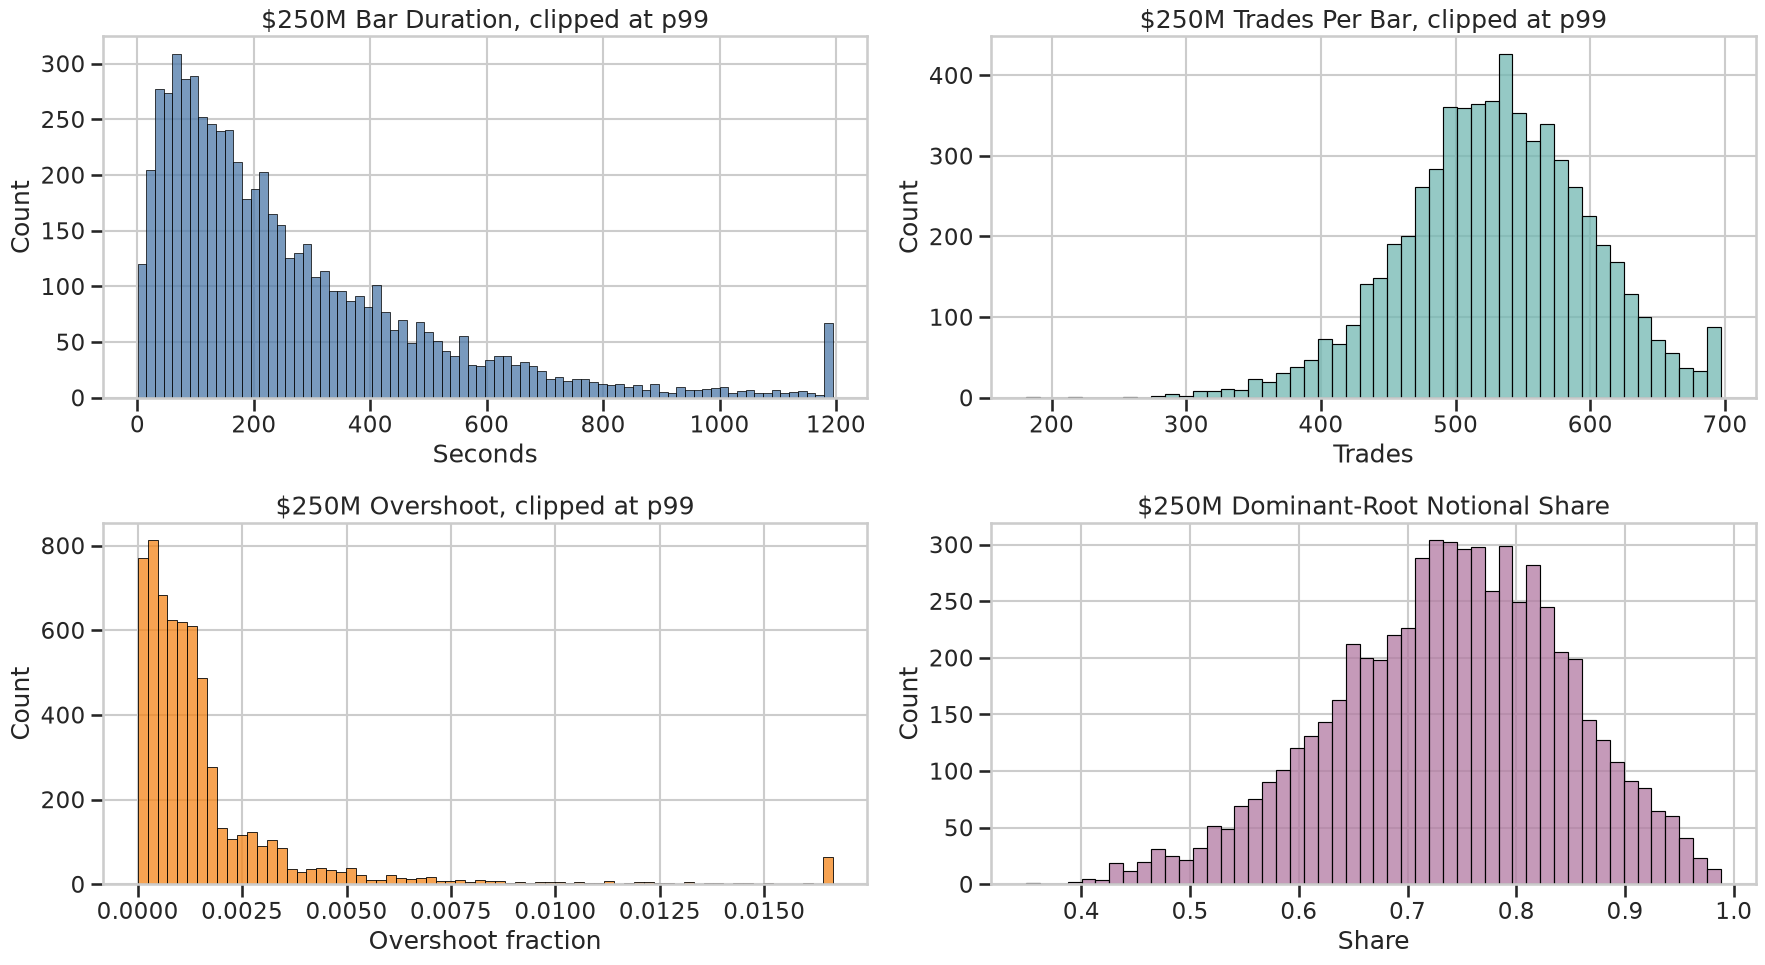

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
sns.histplot(
    primary_complete["duration_seconds"].clip(
        upper=primary_complete["duration_seconds"].quantile(0.99)
    ),
    bins=80,
    ax=axes[0, 0],
    color="#4C78A8",
)
axes[0, 0].set_title("$250M Bar Duration, clipped at p99")
axes[0, 0].set_xlabel("Seconds")

sns.histplot(
    primary_complete["trades"].clip(upper=primary_complete["trades"].quantile(0.99)),
    bins=50,
    ax=axes[0, 1],
    color="#72B7B2",
)
axes[0, 1].set_title("$250M Trades Per Bar, clipped at p99")
axes[0, 1].set_xlabel("Trades")

sns.histplot(
    primary_complete["overshoot_pct"].clip(upper=primary_complete["overshoot_pct"].quantile(0.99)),
    bins=70,
    ax=axes[1, 0],
    color="#F58518",
)
axes[1, 0].set_title("$250M Overshoot, clipped at p99")
axes[1, 0].set_xlabel("Overshoot fraction")

sns.histplot(primary_complete["dominant_share"], bins=50, ax=axes[1, 1], color="#B279A2")
axes[1, 1].set_title("$250M Dominant-Root Notional Share")
axes[1, 1].set_xlabel("Share")
plt.tight_layout()

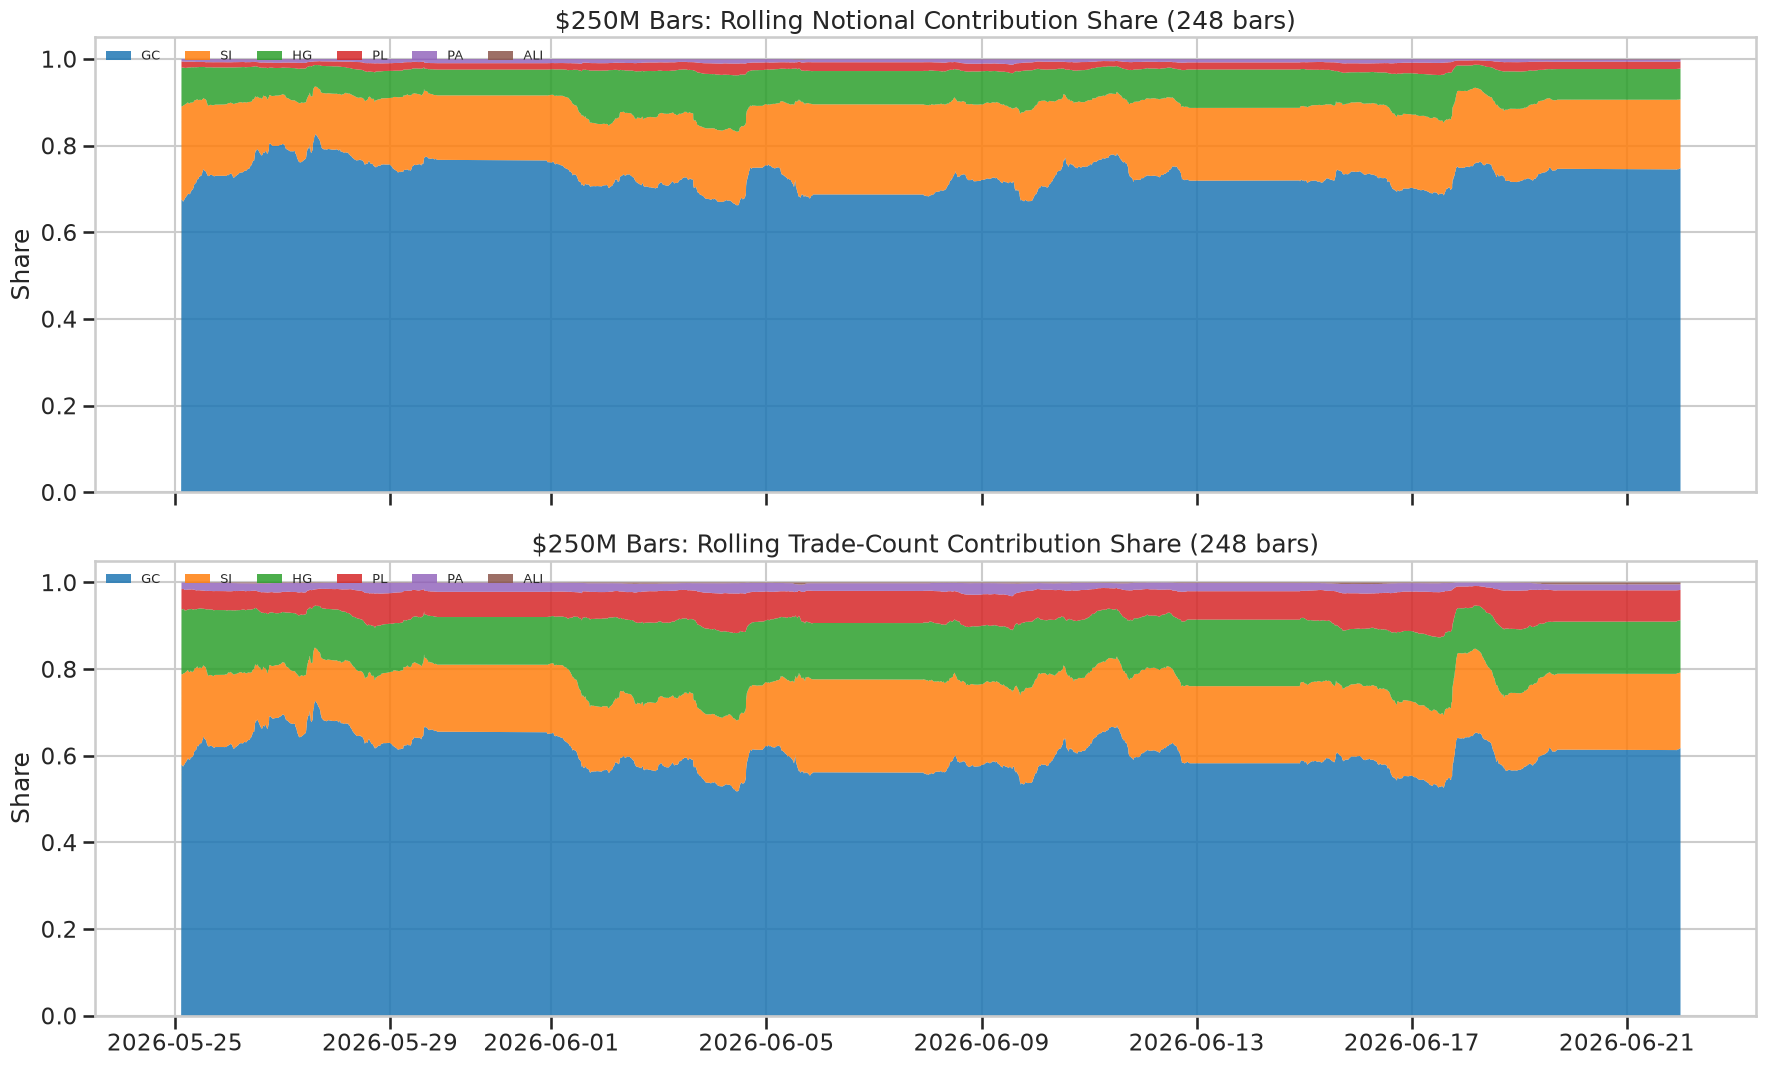

In [13]:
notional_share = primary_complete[[f"{root}_notional" for root in ROOTS]].div(
    primary_complete["bar_notional"], axis=0
)
notional_share.columns = ROOTS
trade_share = primary_complete[[f"{root}_trades" for root in ROOTS]].div(
    primary_complete["trades"], axis=0
)
trade_share.columns = ROOTS

rolling_window = min(250, max(20, len(primary_complete) // 25))
rolling_notional_share = notional_share.rolling(
    rolling_window, min_periods=max(5, rolling_window // 5)
).mean()
rolling_trade_share = trade_share.rolling(
    rolling_window, min_periods=max(5, rolling_window // 5)
).mean()

fig, axes = plt.subplots(2, 1, figsize=(18, 11), sharex=True)
axes[0].stackplot(
    primary_complete["end_ts"],
    [rolling_notional_share[root].fillna(0) for root in ROOTS],
    labels=ROOTS,
    alpha=0.85,
)
axes[0].set_title(f"$250M Bars: Rolling Notional Contribution Share ({rolling_window} bars)")
axes[0].set_ylabel("Share")
axes[0].legend(ncols=6, loc="upper left", fontsize=9)

axes[1].stackplot(
    primary_complete["end_ts"],
    [rolling_trade_share[root].fillna(0) for root in ROOTS],
    labels=ROOTS,
    alpha=0.85,
)
axes[1].set_title(f"$250M Bars: Rolling Trade-Count Contribution Share ({rolling_window} bars)")
axes[1].set_ylabel("Share")
axes[1].legend(ncols=6, loc="upper left", fontsize=9)
plt.tight_layout()

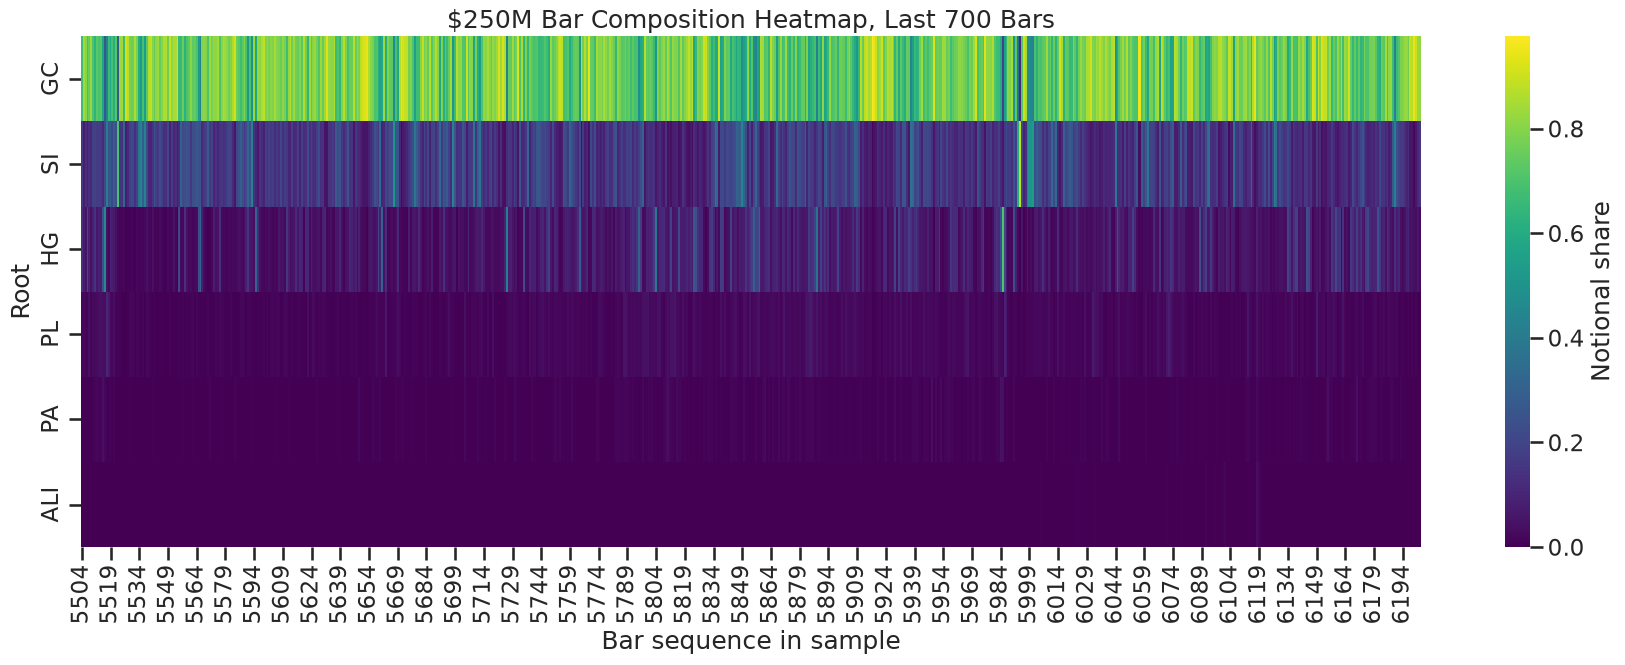

In [14]:
sample_n = min(700, len(primary_complete))
sample = primary_complete.tail(sample_n).copy()
sample_share = sample[[f"{root}_notional" for root in ROOTS]].div(sample["bar_notional"], axis=0)
sample_share.columns = ROOTS

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(sample_share.T, cmap="viridis", cbar_kws={"label": "Notional share"}, ax=ax)
ax.set_title(f"$250M Bar Composition Heatmap, Last {sample_n} Bars")
ax.set_xlabel("Bar sequence in sample")
ax.set_ylabel("Root")
plt.tight_layout()

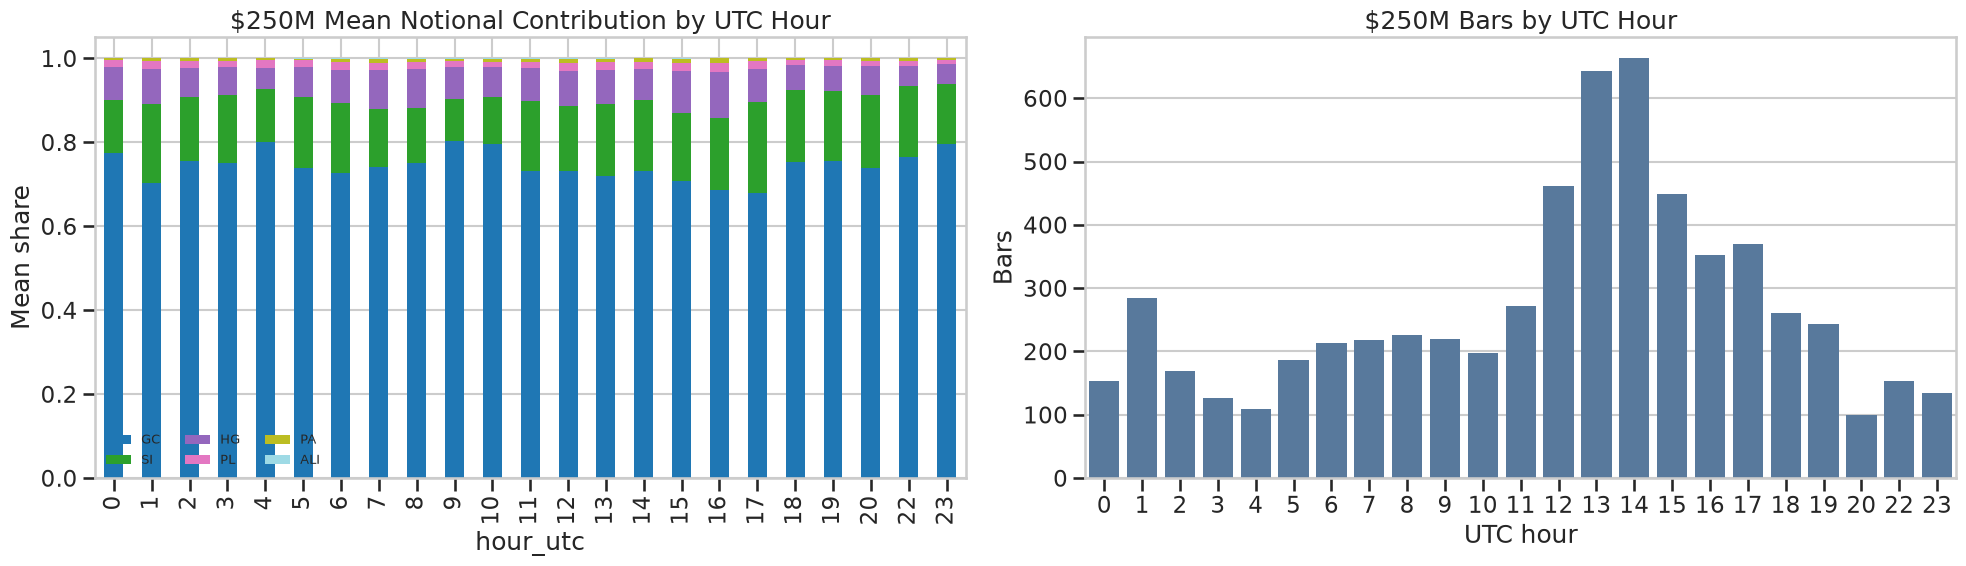

In [15]:
tod = primary_complete.copy()
tod["hour_utc"] = tod["end_ts"].dt.hour
hourly_share = []
for hour, group in tod.groupby("hour_utc"):
    row = {"hour_utc": hour, "bars": len(group)}
    for root in ROOTS:
        row[root] = (group[f"{root}_notional"] / group["bar_notional"]).mean()
    hourly_share.append(row)
hourly_share = pd.DataFrame(hourly_share).sort_values("hour_utc")

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
hourly_share.set_index("hour_utc")[ROOTS].plot(
    kind="bar", stacked=True, ax=axes[0], colormap="tab20"
)
axes[0].set_title("$250M Mean Notional Contribution by UTC Hour")
axes[0].set_ylabel("Mean share")
axes[0].legend(ncols=3, fontsize=9)

sns.barplot(data=hourly_share, x="hour_utc", y="bars", ax=axes[1], color="#4C78A8")
axes[1].set_title("$250M Bars by UTC Hour")
axes[1].set_ylabel("Bars")
axes[1].set_xlabel("UTC hour")
plt.tight_layout()

,root,bars,fraction
0,GC,6111,0.985010
1,SI,58,0.009349
2,HG,34,0.005480
3,PA,1,0.000161


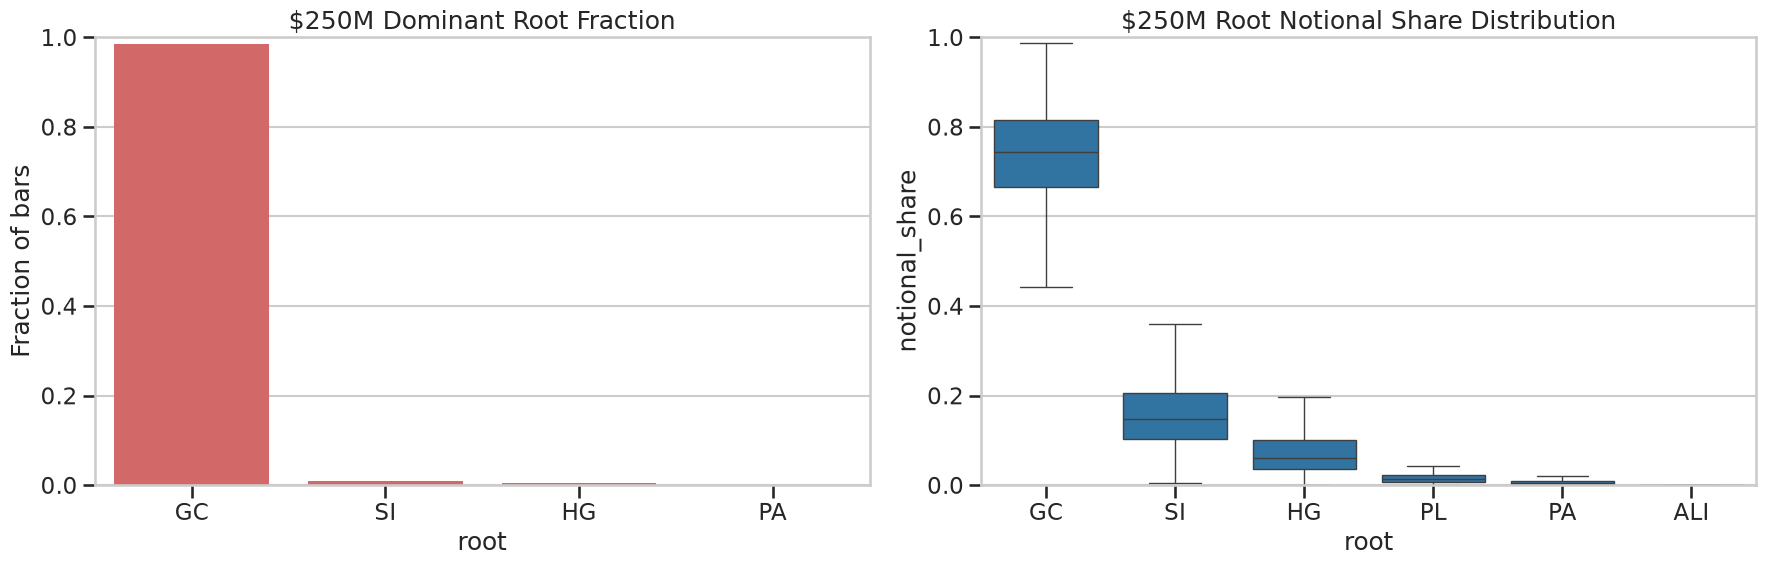

In [16]:
dominant_counts = (
    primary_complete["dominant_root"]
    .value_counts(normalize=False)
    .rename_axis("root")
    .reset_index(name="bars")
)
dominant_counts["fraction"] = dominant_counts["bars"] / dominant_counts["bars"].sum()
display(dominant_counts)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=dominant_counts, x="root", y="fraction", ax=axes[0], color="#E45756")
axes[0].set_title("$250M Dominant Root Fraction")
axes[0].set_ylabel("Fraction of bars")
axes[0].set_ylim(0, 1)

box_data = notional_share.melt(var_name="root", value_name="notional_share")
sns.boxplot(data=box_data, x="root", y="notional_share", ax=axes[1], showfliers=False)
axes[1].set_title("$250M Root Notional Share Distribution")
axes[1].set_ylim(0, 1)
plt.tight_layout()

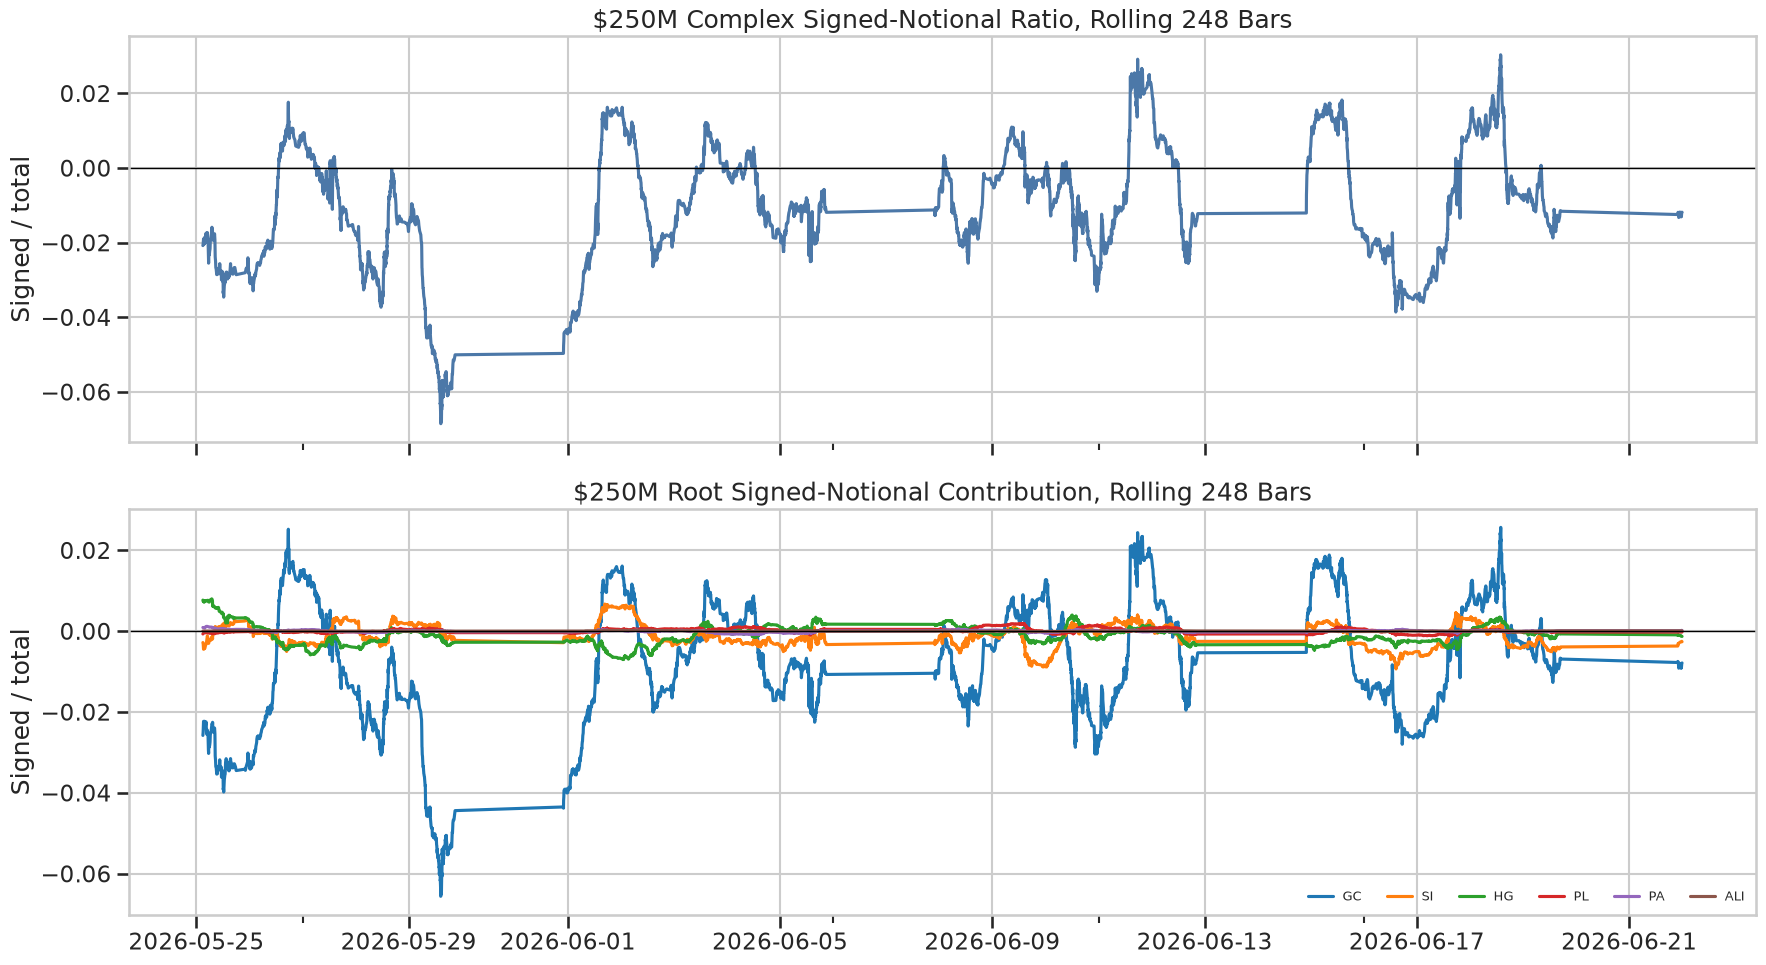

In [17]:
signed_cols = [f"{root}_signed_notional" for root in ROOTS]
signed_share = primary_complete[signed_cols].copy()
signed_share.columns = ROOTS
signed_share = signed_share.div(primary_complete["bar_notional"], axis=0)
rolling_signed = signed_share.rolling(
    rolling_window, min_periods=max(5, rolling_window // 5)
).mean()

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
primary_complete.set_index("end_ts")["complex_signed_notional_ratio"].rolling(
    rolling_window, min_periods=max(5, rolling_window // 5)
).mean().plot(ax=axes[0], color="#4C78A8")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title(f"$250M Complex Signed-Notional Ratio, Rolling {rolling_window} Bars")
axes[0].set_ylabel("Signed / total")

for root in ROOTS:
    axes[1].plot(primary_complete["end_ts"], rolling_signed[root], label=root)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title(f"$250M Root Signed-Notional Contribution, Rolling {rolling_window} Bars")
axes[1].set_ylabel("Signed / total")
axes[1].legend(ncols=6, fontsize=9)
plt.tight_layout()

## Interpretation Notes

- `$250M` is the default because it materially reduces the tick-level behavior seen in `$1M` bars while retaining enough intraday observations for visual inspection.
- `GC` is expected to dominate because it carries most traded notional in the sample.
- `ALI` is included, but it contributes very little to cross-sectional dollar bars over this period. Its role is more visible in trade-count diagnostics than in notional-share diagnostics.
- Overshoot is unavoidable because bars close on whole trades. The overshoot plots show whether the chosen threshold is too small relative to single-trade notional.

## Per-Asset Returns and Volatility

Returns are computed from last-observed trade prices at each cross-sectional bar end. This is a mark-to-market view: if a root does not trade inside a bar, its last observed price is carried forward and the return can be zero. The `active_*` columns restrict the calculation to bars where the root traded inside the current bar.

In [18]:
def compute_bar_endpoint_returns(
    bars_by_threshold: dict[float, pd.DataFrame], trades: pd.DataFrame
) -> tuple[dict[float, pd.DataFrame], pd.DataFrame]:
    returns_by_threshold = {}
    metric_rows = []
    ordered_trades = trades.sort_values(["ts_event", "root"]).copy()

    for threshold, bars in bars_by_threshold.items():
        complete = bars[bars["complete"]].copy().sort_values("end_ts").reset_index(drop=True)
        ends = pd.DataFrame({"end_ts": pd.to_datetime(complete["end_ts"], utc=True)})
        prices = []
        traded_masks = {}
        for root in ROOTS:
            root_trades = (
                ordered_trades.loc[ordered_trades["root"].eq(root), ["ts_event", "price"]]
                .sort_values("ts_event")
                .reset_index(drop=True)
            )
            px = pd.merge_asof(
                ends, root_trades, left_on="end_ts", right_on="ts_event", direction="backward"
            )["price"]
            prices.append(px.rename(root))
            traded_masks[root] = complete[f"{root}_trades"].to_numpy() > 0

        price_frame = pd.concat(prices, axis=1)
        ret_frame = np.log(price_frame).diff()
        ret_frame.insert(0, "end_ts", complete["end_ts"])
        returns_by_threshold[threshold] = ret_frame

        for root in ROOTS:
            series = ret_frame[root].dropna()
            active_mask = pd.Series(traded_masks[root], index=ret_frame.index)
            active_series = ret_frame.loc[active_mask, root].dropna()
            metric_rows.append(
                {
                    "threshold_m": threshold / 1e6,
                    "root": root,
                    "bars": len(series),
                    "mean_bps": series.mean() * 10_000,
                    "vol_bps": series.std(ddof=1) * 10_000,
                    "median_bps": series.median() * 10_000,
                    "p01_bps": series.quantile(0.01) * 10_000,
                    "p99_bps": series.quantile(0.99) * 10_000,
                    "active_bar_fraction": active_mask.mean(),
                    "active_mean_bps": active_series.mean() * 10_000
                    if len(active_series)
                    else np.nan,
                    "active_vol_bps": active_series.std(ddof=1) * 10_000
                    if len(active_series) > 1
                    else np.nan,
                }
            )

    metrics = pd.DataFrame(metric_rows)
    metrics.to_csv(CACHE_DIR / f"return_metrics_{START:%Y%m%d}_{END:%Y%m%d}.csv", index=False)
    return returns_by_threshold, metrics


returns_by_threshold, return_metrics = compute_bar_endpoint_returns(bars_by_threshold, trades)
primary_return_metrics = return_metrics[
    return_metrics["threshold_m"].eq(PRIMARY_THRESHOLD / 1e6)
].copy()
display(primary_return_metrics)

,threshold_m,root,bars,mean_bps,vol_bps,median_bps,p01_bps,p99_bps,active_bar_fraction,active_mean_bps,active_vol_bps
6,250.0,GC,6203,-0.145088,37.837891,-0.230311,-144.639351,144.464502,1.000000,-0.145088,37.837891
7,250.0,SI,6203,-0.264970,32.203154,0.000000,-86.344449,89.235492,1.000000,-0.264970,32.203154
8,250.0,HG,6203,-0.028921,53.603756,0.000000,-227.923322,223.180784,0.999678,-0.028930,53.612401
9,250.0,PL,6203,-0.259918,34.824140,0.000000,-116.174390,113.169167,0.998066,-0.260422,34.857877
10,250.0,PA,6203,-0.133654,41.459359,0.000000,-161.156644,161.667006,0.949710,-0.140733,42.543254
11,250.0,ALI,6192,-0.061552,62.000276,0.000000,-173.159630,162.412608,0.259349,-0.237023,121.692967


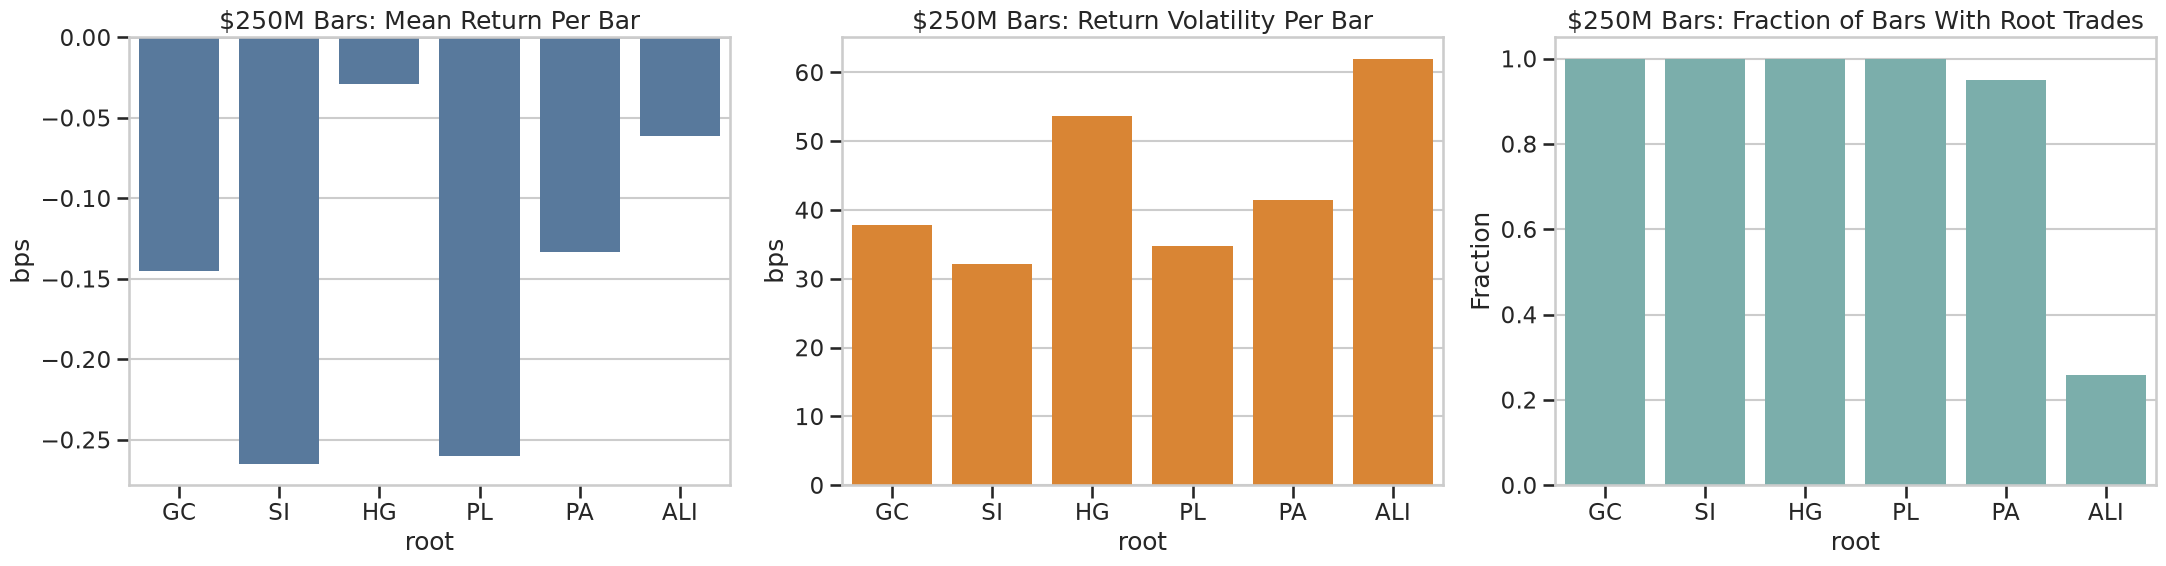

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
sns.barplot(data=primary_return_metrics, x="root", y="mean_bps", ax=axes[0], color="#4C78A8")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("$250M Bars: Mean Return Per Bar")
axes[0].set_ylabel("bps")

sns.barplot(data=primary_return_metrics, x="root", y="vol_bps", ax=axes[1], color="#F58518")
axes[1].set_title("$250M Bars: Return Volatility Per Bar")
axes[1].set_ylabel("bps")

sns.barplot(
    data=primary_return_metrics, x="root", y="active_bar_fraction", ax=axes[2], color="#72B7B2"
)
axes[2].set_title("$250M Bars: Fraction of Bars With Root Trades")
axes[2].set_ylabel("Fraction")
axes[2].set_ylim(0, 1.05)
plt.tight_layout()

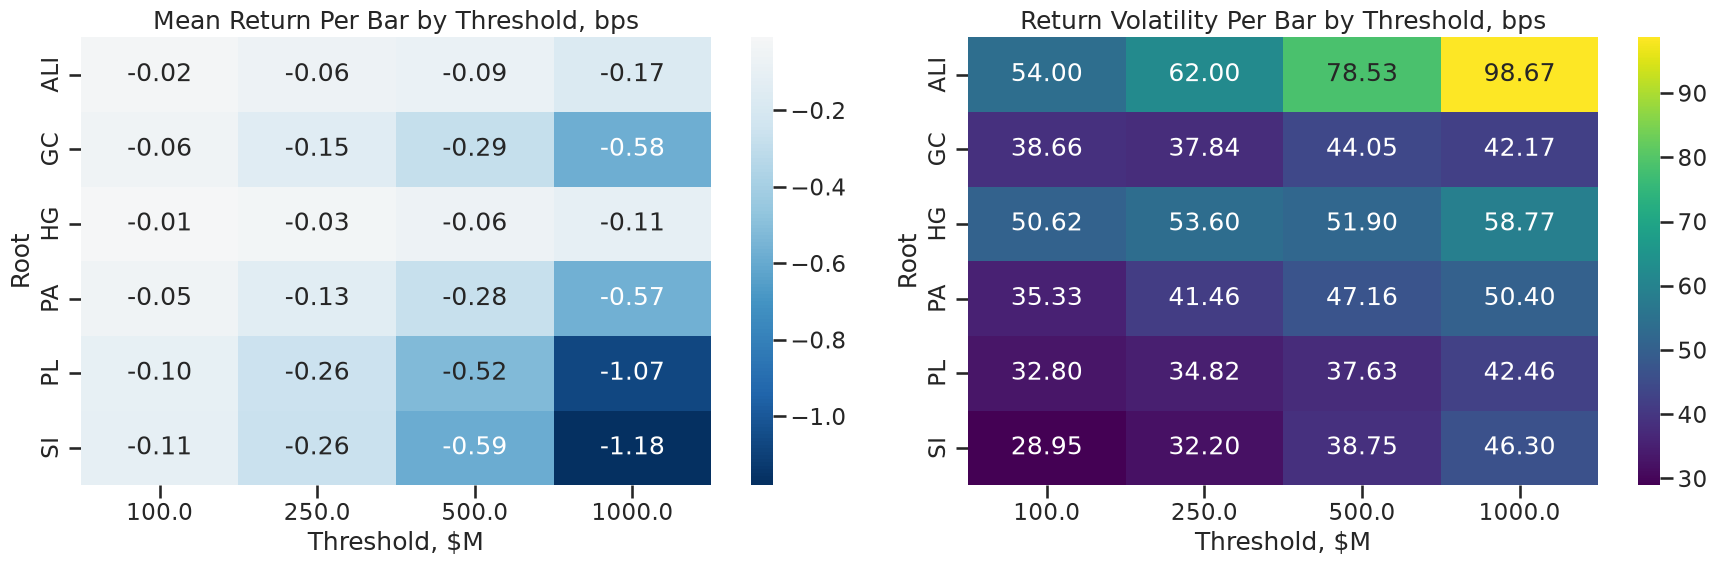

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
mean_heat = return_metrics.pivot(index="root", columns="threshold_m", values="mean_bps")
vol_heat = return_metrics.pivot(index="root", columns="threshold_m", values="vol_bps")
sns.heatmap(mean_heat, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0])
axes[0].set_title("Mean Return Per Bar by Threshold, bps")
axes[0].set_xlabel("Threshold, $M")
axes[0].set_ylabel("Root")

sns.heatmap(vol_heat, annot=True, fmt=".2f", cmap="viridis", ax=axes[1])
axes[1].set_title("Return Volatility Per Bar by Threshold, bps")
axes[1].set_xlabel("Threshold, $M")
axes[1].set_ylabel("Root")
plt.tight_layout()